Error cuadrático medio: 48358736.64743516


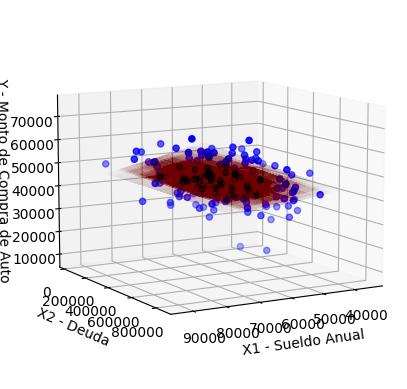

In [ ]:
# Monjaraz Briseño Luis Fernando
# A

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Cargar los datos de 'car_purchasing.csv', seleccionando las columnas 5, 7 y 8
datos = pd.read_csv('car_purchasing.csv', usecols=[5, 7, 8], encoding='latin-1')

# Separar las variables independientes (X) y dependiente (y)
X = datos.iloc[:, :-1].values  # Las dos primeras columnas como variables independientes
y = datos.iloc[:, -1].values   # La última columna como variable dependiente

# Dividir los datos en conjunto de entrenamiento (70%) y prueba (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# Crear el modelo de regresión lineal
modelo = LinearRegression()

# Entrenar el modelo en el conjunto de entrenamiento
modelo.fit(X_train, y_train)

# Predecir en el conjunto de prueba
y_pred = modelo.predict(X_test)

# Calcular el error cuadrático medio
error = mean_squared_error(y_test, y_pred)
print(f'Error cuadrático medio: {error}')

# Graficar los datos y el hiperplano resultante
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# Scatter plot de los datos de prueba
ax.scatter(X_test[:, 0], X_test[:, 1], y_test, c='blue', marker='o')

# Crear una malla para graficar el hiperplano
xx, yy = np.meshgrid(X_test[:, 0], X_test[:, 1])

# Ecuación del hiperplano para las predicciones
zz = modelo.intercept_ + modelo.coef_[0]*xx + modelo.coef_[1]*yy
ax.plot_surface(xx, yy, zz, color='r', alpha=0.002)

# Etiquetas de los ejes
ax.set_xlabel('X1 - Sueldo Anual')
ax.set_ylabel('X2 - Deuda')
ax.set_zlabel('Y - Monto de Compra de Auto')

ax.azim = 60
ax.elev = 10
plt.show()


Error cuadrático medio promedio: 45411246.83115889


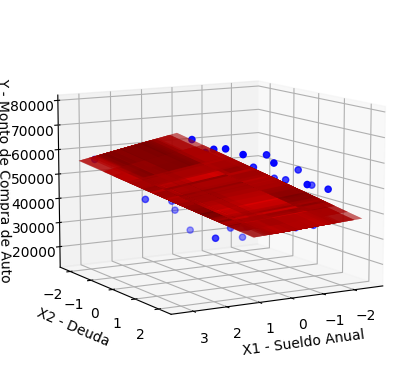

In [ ]:
# Monjaraz Briseño Luis Fernando
# B

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler

# Definir la clase de Regresión Lineal Múltiple con Gradiente Descendente
class RegresionLinealMultiple:
    def __init__(self, learning_rate=0.001, n_iter=1000):
        self.learning_rate = learning_rate
        self.n_iter = n_iter
        self.coef_ = None
        self.intercept_ = None

    def fit(self, X, y):
        # Agregar una columna de unos para el término de sesgo (intercepto)
        X_con_intercepto = np.column_stack((np.ones(len(X)), X))

        # Inicializar los coeficientes aleatoriamente
        self.coef_ = np.random.randn(X_con_intercepto.shape[1])

        # Gradiente descendente
        for _ in range(self.n_iter):
            # Cálculo del gradiente
            gradient = -2 * X_con_intercepto.T @ (y - X_con_intercepto @ self.coef_)

            # Actualización de los coeficientes
            self.coef_ -= self.learning_rate * gradient

        # El primer valor de coef_ corresponde al intercepto
        self.intercept_ = self.coef_[0]
        self.coef_ = self.coef_[1:]

    def predict(self, X):
        # Agregar una columna de unos para el término de sesgo (intercepto)
        X_con_intercepto = np.column_stack((np.ones(len(X)), X))

        # Calcular las predicciones
        return X_con_intercepto @ np.concatenate(([self.intercept_], self.coef_))

# Cargar los datos de 'car_purchasing.csv', seleccionando las columnas 5, 7 y 8
datos = pd.read_csv('car_purchasing.csv', usecols=[5, 7, 8], encoding='latin-1')

# Separar las variables independientes (X) y dependiente (y)
X = datos.iloc[:, :-1].values  # Las dos primeras columnas como variables independientes
y = datos.iloc[:, -1].values   # La última columna como variable dependiente

# Normalizar los datos
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Crear el modelo de regresión lineal múltiple con gradiente
modelo = RegresionLinealMultiple(learning_rate=0.001, n_iter=1000)

# Validación cruzada con K pliegues (K-Fold Cross Validation)
kf = KFold(n_splits=5, shuffle=True, random_state=0)
errores = []

for train_index, test_index in kf.split(X):
    # Dividir los datos en conjuntos de entrenamiento y prueba
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Entrenar el modelo en el conjunto de entrenamiento
    modelo.fit(X_train, y_train)

    # Predecir en el conjunto de prueba
    y_pred = modelo.predict(X_test)

    # Calcular el error cuadrático medio manualmente
    error = np.mean((y_test - y_pred) ** 2)
    errores.append(error)

# Promedio del error de validación cruzada
error_promedio = np.mean(errores)
print(f'Error cuadrático medio promedio: {error_promedio}')

# Graficar los datos y el hiperplano resultante utilizando el último fold
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# Scatter plot de los datos de prueba
ax.scatter(X_test[:, 0], X_test[:, 1], y_test, c='blue', marker='o')

# Crear una malla para graficar el hiperplano
xx, yy = np.meshgrid(X_test[:, 0], X_test[:, 1])

# Ecuación del hiperplano para las predicciones
zz = modelo.intercept_ + modelo.coef_[0]*xx + modelo.coef_[1]*yy
ax.plot_surface(xx, yy, zz, color='r', alpha=0.2)  # Superficie semitransparente

# Etiquetas de los ejes
ax.set_xlabel('X1 - Sueldo Anual')
ax.set_ylabel('X2 - Deuda')
ax.set_zlabel('Y - Monto de Compra de Auto')

ax.azim = 60
ax.elev = 10
plt.show()


Error cuadrático medio promedio: 45372149.27325456


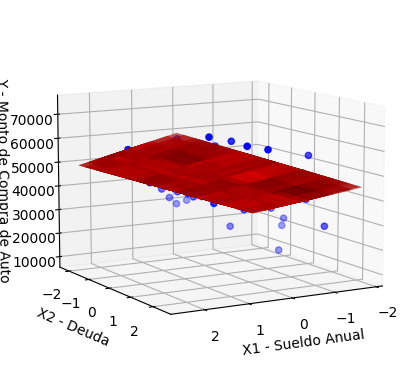

In [ ]:
# Monjaraz Briseño Luis Fernando
# Extra: Sin las librerias from sklearn.model_selection import KFold y from sklearn.preprocessing import StandardScaler

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Definir la clase de Regresión Lineal Múltiple con Gradiente Descendente
class RegresionLinealMultiple:
    def __init__(self, learning_rate=0.001, n_iter=1000):
        self.learning_rate = learning_rate
        self.n_iter = n_iter
        self.coef_ = None
        self.intercept_ = None

    def fit(self, X, y):
        # Agregar una columna de unos para el término de sesgo (intercepto)
        X_con_intercepto = np.column_stack((np.ones(len(X)), X))

        # Inicializar los coeficientes aleatoriamente
        self.coef_ = np.random.randn(X_con_intercepto.shape[1])

        # Gradiente descendente
        for _ in range(self.n_iter):
            # Cálculo del gradiente
            gradient = -2 * X_con_intercepto.T @ (y - X_con_intercepto @ self.coef_)

            # Actualización de los coeficientes
            self.coef_ -= self.learning_rate * gradient

        # El primer valor de coef_ corresponde al intercepto
        self.intercept_ = self.coef_[0]
        self.coef_ = self.coef_[1:]

    def predict(self, X):
        # Agregar una columna de unos para el término de sesgo (intercepto)
        X_con_intercepto = np.column_stack((np.ones(len(X)), X))

        # Calcular las predicciones
        return X_con_intercepto @ np.concatenate(([self.intercept_], self.coef_))

# Implementación manual de la normalización
def normalizar(X):
    media = np.mean(X, axis=0)
    std = np.std(X, axis=0)
    return (X - media) / std

# Implementación manual de la validación cruzada K-fold
def kfold_split(X, y, n_splits=5):
    indices = np.arange(len(X))
    np.random.shuffle(indices)
    fold_sizes = len(X) // n_splits
    for i in range(n_splits):
        test_idx = indices[i*fold_sizes:(i+1)*fold_sizes]
        train_idx = np.concatenate([indices[:i*fold_sizes], indices[(i+1)*fold_sizes:]])
        yield train_idx, test_idx

# Cargar los datos de 'car_purchasing.csv', seleccionando las columnas 5, 7 y 8
datos = pd.read_csv('car_purchasing.csv', usecols=[5, 7, 8], encoding='latin-1')

# Separar las variables independientes (X) y dependiente (y)
X = datos.iloc[:, :-1].values  # Las dos primeras columnas como variables independientes
y = datos.iloc[:, -1].values   # La última columna como variable dependiente

# Normalizar los datos
X = normalizar(X)

# Crear el modelo de regresión lineal múltiple con gradiente
modelo = RegresionLinealMultiple(learning_rate=0.001, n_iter=1000)

# Validación cruzada con K pliegues (K-Fold Cross Validation)
errores = []

for train_index, test_index in kfold_split(X, y, n_splits=5):
    # Dividir los datos en conjuntos de entrenamiento y prueba
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Entrenar el modelo en el conjunto de entrenamiento
    modelo.fit(X_train, y_train)

    # Predecir en el conjunto de prueba
    y_pred = modelo.predict(X_test)

    # Calcular el error cuadrático medio manualmente
    error = np.mean((y_test - y_pred) ** 2)
    errores.append(error)

# Promedio del error de validación cruzada
error_promedio = np.mean(errores)
print(f'Error cuadrático medio promedio: {error_promedio}')

# Graficar los datos y el hiperplano resultante utilizando el último fold
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# Scatter plot de los datos de prueba
ax.scatter(X_test[:, 0], X_test[:, 1], y_test, c='blue', marker='o')

# Crear una malla para graficar el hiperplano
xx, yy = np.meshgrid(X_test[:, 0], X_test[:, 1])

# Ecuación del hiperplano para las predicciones
zz = modelo.intercept_ + modelo.coef_[0]*xx + modelo.coef_[1]*yy
ax.plot_surface(xx, yy, zz, color='r', alpha=0.2)  # Superficie semitransparente

# Etiquetas de los ejes
ax.set_xlabel('X1 - Sueldo Anual')
ax.set_ylabel('X2 - Deuda')
ax.set_zlabel('Y - Monto de Compra de Auto')

ax.azim = 60
ax.elev = 10
plt.show()
